# Q4: Classification on MNIST dataset

In [56]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Read in dataset
train_df = pd.read_csv('train_MNIST.csv')
test_df  = pd.read_csv('test_MNIST.csv')

X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values
X_test  = test_df.iloc[:, 1:].values
y_test  = test_df.iloc[:, 0].values

## (a) Logistic Regression

Optimization: Ajusted regulation strength C

In [23]:
clf = LogisticRegression(C=5,max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
test_error = 1 - accuracy_score(y_test, y_pred)
print(f'Test error: {test_error:.3f}')

Test error: 0.117


## (b) Boosting Tree

Ajusted tree numbers, max_depth

In [30]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gbc = GradientBoostingClassifier(n_estimators=1000, learning_rate=0.1, validation_fraction=0.1, max_depth=3, random_state=0)
gbc.fit(X_train, y_train)

y_pred = gbc.predict(X_test)
test_error = 1 - accuracy_score(y_test, y_pred)
print(f'Test error: {test_error:.3f}')

Test error: 0.120


## (c) SVM

In [40]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(kernel='linear', C=1.0)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
test_error = 1 - accuracy_score(y_test, y_pred)
print(f'Test error: {test_error:.3f}')

Test error: 0.090


## (d) CNN

In [63]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Reshape the data
X_train_img = X_train.reshape(-1, 1, 14, 14)
X_test_img  = X_test.reshape(-1, 1, 14, 14)

# Turn into Torch tensors
X_train_torch = torch.tensor(X_train_img, dtype=torch.float32)
y_train_torch = torch.tensor(y_train, dtype=torch.long)
X_test_torch  = torch.tensor(X_test_img,  dtype=torch.float32)
y_test_torch  = torch.tensor(y_test, dtype=torch.long)

# Loader
train_loader = DataLoader(TensorDataset(X_train_torch, y_train_torch),
                          batch_size=128, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_torch, y_test_torch),
                          batch_size=256, shuffle=False)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),   # 14×14 → 14×14
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 7×7
            nn.Conv2d(16, 32, 3, padding=1),  # 7×7
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 3×3
            nn.Flatten(),
            nn.Linear(32*3*3, 10)
        )
    def forward(self, x): return self.net(x)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNN().to(device)
crit = nn.CrossEntropyLoss()
opt  = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(100):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        preds = torch.cat([model(xb.to(device)).argmax(1)
                           for xb, _ in test_loader])
    test_error = 1 - (preds == y_test_torch.to(device)).float().mean().item()
    if (epoch+1)%10 == 0 :
        print(f'Epoch {epoch+1}  test error {test_error:.3f}')

Epoch 10  test error 0.268
Epoch 20  test error 0.171
Epoch 30  test error 0.120
Epoch 40  test error 0.107
Epoch 50  test error 0.087
Epoch 60  test error 0.087
Epoch 70  test error 0.077
Epoch 80  test error 0.080
Epoch 90  test error 0.080
Epoch 100  test error 0.067


## (e) Another method: Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    n_jobs=-1,
    random_state=0
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
test_error = 1 - accuracy_score(y_test, y_pred)
print(f'Test error: {test_error:.3f}')

Test error: 0.090


# Q5: Dimension Reduction on a small MNIST dataset

In [68]:
import pandas as pd
import numpy as np

data = pd.read_csv('MNIST-DR.csv')
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

## (a) PCA

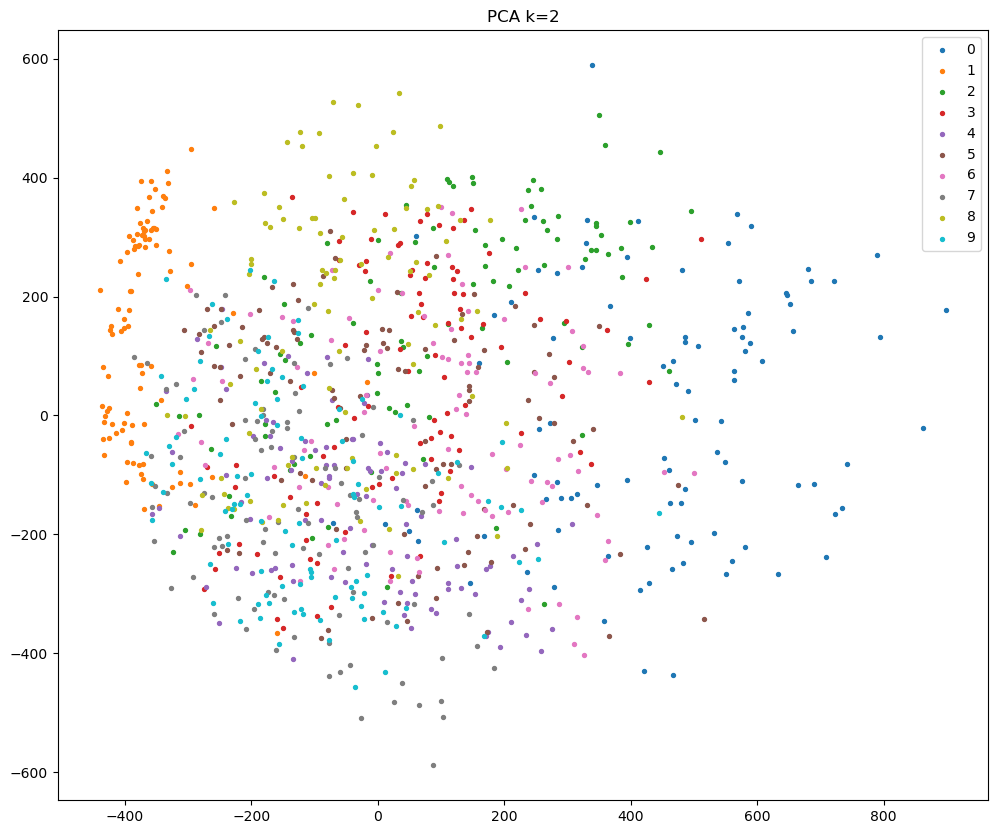

Fisher Discrimination Ratio: 1.4210


In [74]:
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 10))
for i in range(10):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=str(i), s=8)
plt.legend()
plt.title('PCA k=2')
plt.show()

def fisher_ratio(X, y):
    classes = np.unique(y)
    means = np.array([X[y == c].mean(axis=0) for c in classes])
    overall_mean = X.mean(axis=0)
    Sw = np.sum([np.cov(X[y == c], rowvar=False) * np.sum(y == c) for c in classes], axis=0)
    Sb = np.sum([np.outer(means[i] - overall_mean, means[i] - overall_mean) * np.sum(y == c) for i, c in enumerate(classes)], axis=0)
    eigvals = np.linalg.eigvals(np.linalg.pinv(Sw) @ Sb)
    return np.max(eigvals)

print(f'Fisher Discrimination Ratio: {fisher_ratio(X_pca, y):.4f}')

## (b) t-SNE

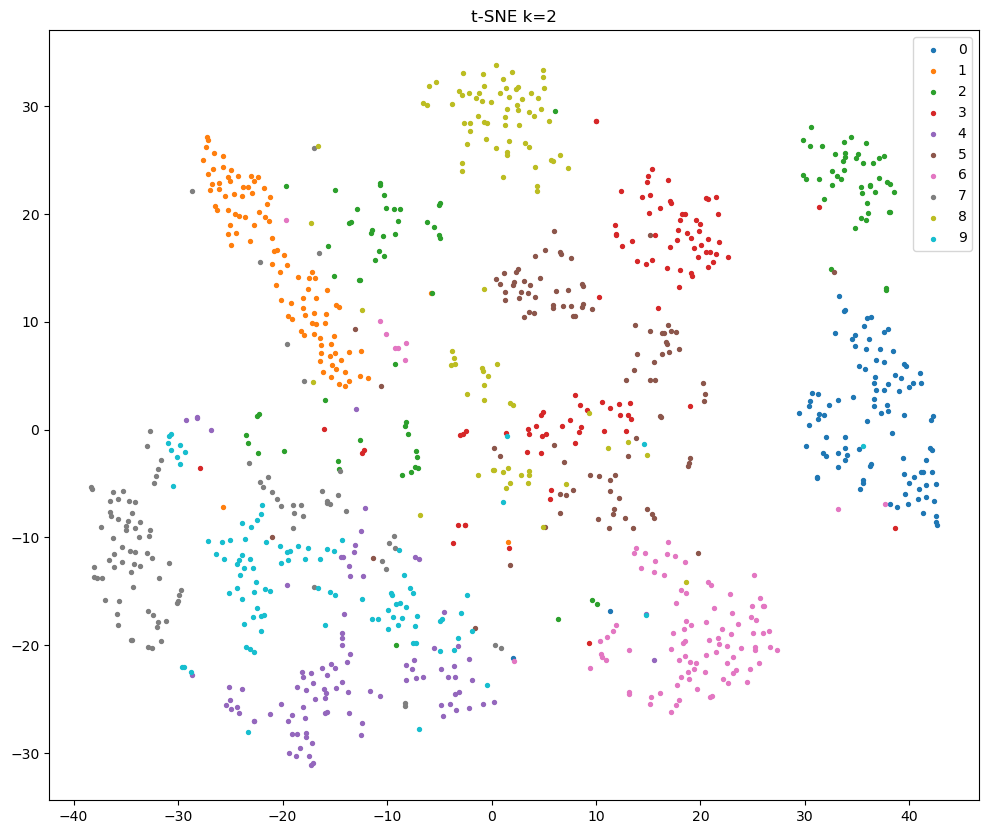

Fisher Discrimination Ratio: 3.1351


In [73]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 10))
for i in range(10):
    plt.scatter(X_tsne[y == i, 0], X_tsne[y == i, 1], label=str(i), s=8)
plt.legend()
plt.title('t-SNE k=2')
plt.show()

print(f'Fisher Discrimination Ratio: {fisher_ratio(X_tsne, y):.4f}')

## (c) ISOMAP

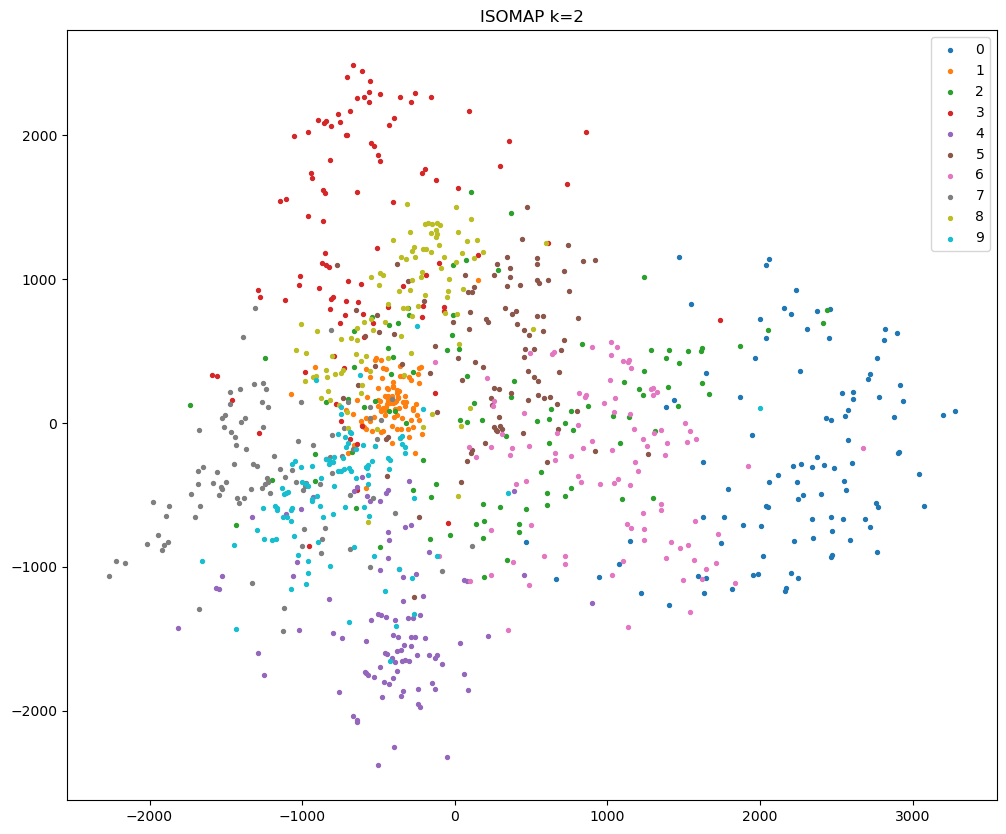

Fisher Discrimination Ratio: 3.9975


In [78]:
from sklearn.manifold import Isomap

iso = Isomap(n_components=2)
X_iso = iso.fit_transform(X)

plt.figure(figsize=(12, 10))
for i in range(10):
    plt.scatter(X_iso[y == i, 0], X_iso[y == i, 1], label=str(i), s=8)
plt.legend()
plt.title('ISOMAP k=2')
plt.show()

print(f'Fisher Discrimination Ratio: {fisher_ratio(X_iso, y):.4f}')

## (d) VAE

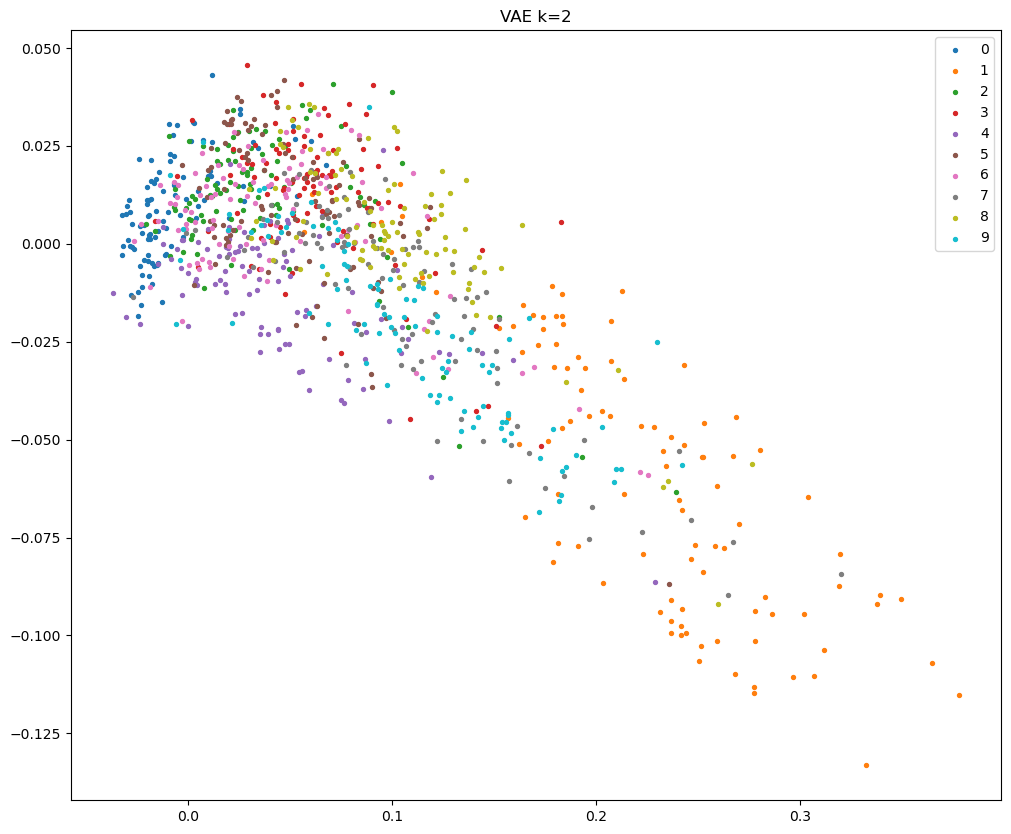

Fisher Discrimination Ratio: 1.6052


In [125]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

X_tensor = torch.FloatTensor(X / 255.0)
loader = DataLoader(TensorDataset(X_tensor), batch_size=256, shuffle=True)

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(196, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU())
        self.mu = nn.Linear(64, 2)
        self.logvar = nn.Linear(64, 2)
        self.dec = nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, 196), nn.Sigmoid())
    def forward(self, x):
        z = self.enc(x)
        mu, logvar = self.mu(z), self.logvar(z)
        eps = torch.randn_like(mu)
        z = mu + eps * torch.exp(0.5 * logvar)
        return self.dec(z), mu, logvar

vae = VAE()
opt = torch.optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(20):
    for (xb,) in loader:
        recon, mu, logvar = vae(xb)
        loss = ((recon - xb) ** 2).sum() + 0.5 * (mu ** 2 + torch.exp(logvar) - logvar - 1).sum()
        opt.zero_grad()
        loss.backward()
        opt.step()

with torch.no_grad():
    z = vae.enc(X_tensor)
    mu = vae.mu(z).numpy()

plt.figure(figsize=(12, 10))
for i in range(10):
    plt.scatter(mu[y == i, 0], mu[y == i, 1], label=str(i), s=8)
plt.legend()
plt.title('VAE k=2')
plt.show()

print(f'Fisher Discrimination Ratio: {fisher_ratio(mu, y):.4f}')

## (e) Another method: LDA

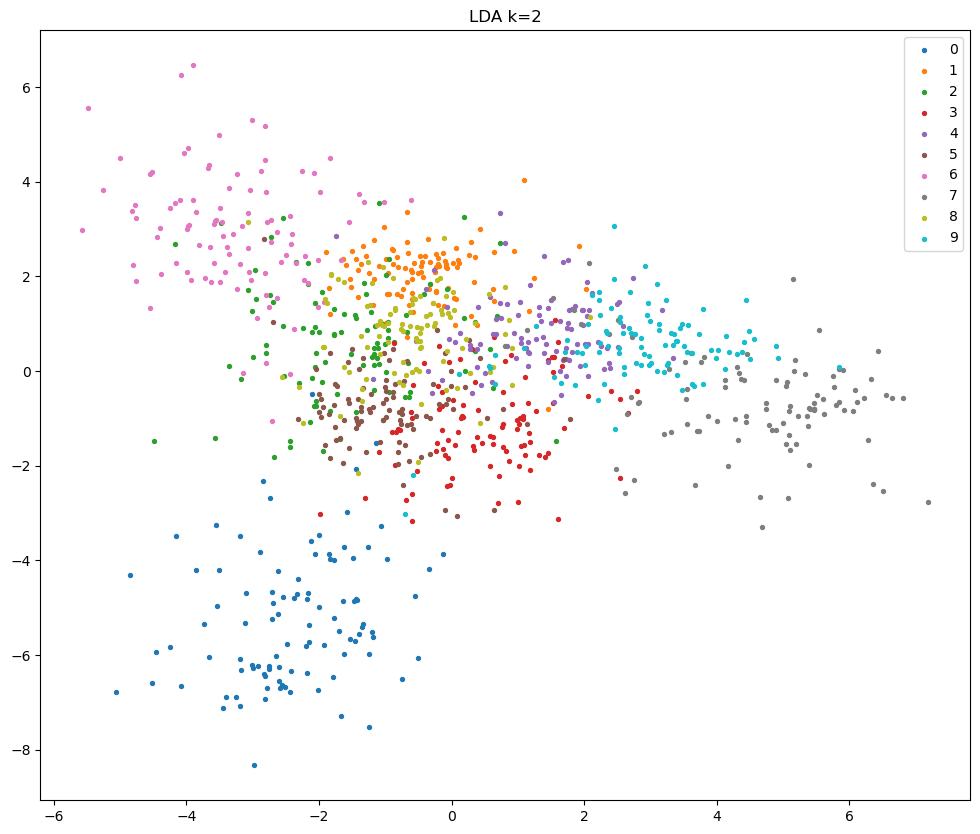

Fisher Discrimination Ratio: 5.1145


In [128]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

plt.figure(figsize=(12, 10))
for i in range(10):
    plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], label=str(i), s=8)
plt.legend()
plt.title('LDA k=2')
plt.show()

print(f'Fisher Discrimination Ratio: {fisher_ratio(X_lda, y):.4f}')